In [206]:
#importing usefull library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit,GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline

from scipy import stats

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeRegressor

In [207]:
#Getting the view of the data
data_url  = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
data  = pd.read_csv(data_url,sep = ";")

In [205]:
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [208]:
#Separate label with features
features_list = data.columns[:-1].values
label = [data.columns[-1]]


In [209]:
print(features_list)
print(label)

['fixed acidity' 'volatile acidity' 'citric acid' 'residual sugar'
 'chlorides' 'free sulfur dioxide' 'total sulfur dioxide' 'density' 'pH'
 'sulphates' 'alcohol']
['quality']


In [210]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [211]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [212]:
data['quality'].value_counts()

,count
quality,
5,681
6,638
7,199
4,53
8,18
3,10


In [213]:
data.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

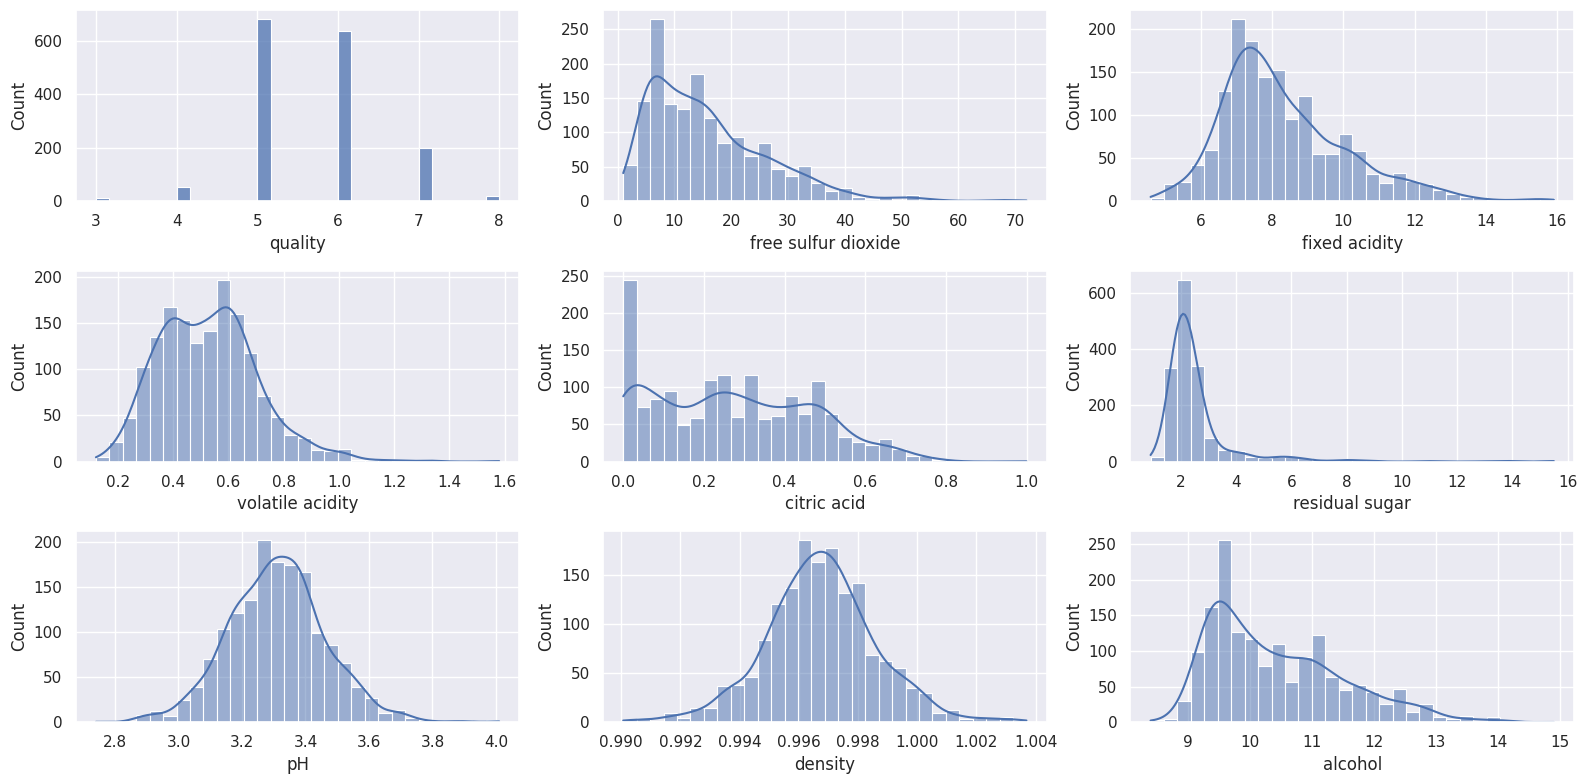

In [214]:
#Lets look at the features how they vary
fig, axes = plt.subplots(3, 3, figsize=(16, 8))
sns.set()
sns.histplot(data['quality'],ax=axes[0, 0])
sns.histplot(data['free sulfur dioxide'],bins = 30,kde = True,ax=axes[0, 1])
sns.histplot(data['fixed acidity'],bins = 30,kde = True,ax=axes[0, 2])
sns.histplot(data['volatile acidity'],bins = 30,kde = True,ax=axes[1, 0])
sns.histplot(data['citric acid'],bins = 30,kde = True,ax=axes[1, 1])
sns.histplot(data['residual sugar'],bins = 30,kde = True,ax=axes[1, 2])
sns.histplot(data['pH'],bins = 30,kde = True,ax=axes[2, 0])
sns.histplot(data['density'],bins = 30,kde = True,ax=axes[2, 1])
sns.histplot(data['alcohol'],bins = 30,kde = True,ax=axes[2, 2])

plt.tight_layout()
plt.show()

But in the distribution we can see that label is not uniform(data is not uniform) that is why we have to use stratified sampling

In [215]:
#As we can see in first visualization that label is not uniform so we will use stratifiedShuffleSplit rather train_test_score
split = StratifiedShuffleSplit(n_splits = 1,test_size = 0.2,random_state = 42)
for train_index,test_index in split.split(data,data['quality']):
  strata_train_set = data.loc[train_index]
  strata_test_set = data.loc[test_index]

In [216]:
strata_train_set

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1542,6.7,0.855,0.02,1.90,0.064,29.0,38.0,0.99472,3.30,0.56,10.75,6
1558,6.9,0.630,0.33,6.70,0.235,66.0,115.0,0.99787,3.22,0.56,9.50,5
344,11.9,0.570,0.50,2.60,0.082,6.0,32.0,1.00060,3.12,0.78,10.70,6
924,8.6,0.470,0.27,2.30,0.055,14.0,28.0,0.99516,3.18,0.80,11.20,5
971,10.4,0.260,0.48,1.90,0.066,6.0,10.0,0.99724,3.33,0.87,10.90,6
...,...,...,...,...,...,...,...,...,...,...,...,...
1056,8.9,0.480,0.53,4.00,0.101,3.0,10.0,0.99586,3.21,0.59,12.10,7
1394,6.4,0.570,0.14,3.90,0.070,27.0,73.0,0.99669,3.32,0.48,9.20,5
337,7.8,0.430,0.32,2.80,0.080,29.0,58.0,0.99740,3.31,0.64,10.30,5
539,11.2,0.500,0.74,5.15,0.100,5.0,17.0,0.99960,3.22,0.62,11.20,5


In [217]:
strata_test_set

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
963,8.8,0.27,0.39,2.0,0.100,20.0,27.0,0.99546,3.15,0.69,11.2,6
475,9.6,0.68,0.24,2.2,0.087,5.0,28.0,0.99880,3.14,0.60,10.2,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
329,10.7,0.46,0.39,2.0,0.061,7.0,15.0,0.99810,3.18,0.62,9.5,5
149,8.2,0.40,0.44,2.8,0.089,11.0,43.0,0.99750,3.53,0.61,10.5,6
...,...,...,...,...,...,...,...,...,...,...,...,...
1173,7.6,0.36,0.31,1.7,0.079,26.0,65.0,0.99716,3.46,0.62,9.5,6
827,7.1,0.46,0.14,2.8,0.076,15.0,37.0,0.99624,3.36,0.49,10.7,5
356,11.5,0.41,0.52,3.0,0.080,29.0,55.0,1.00010,3.26,0.88,11.0,5
1287,8.0,0.60,0.08,2.6,0.056,3.0,7.0,0.99286,3.22,0.37,13.0,5


In [218]:

strata_dist = strata_test_set['quality'].value_counts()/len(strata_test_set)
overall_dist = data['quality'].value_counts()/len(data)

In [220]:
#here we are getting the overview of the how the data is extracted
dist_comparison = pd.DataFrame({'overall':overall_dist,'strata_dist':strata_dist})
dist_comparison['diff(s-o)'] = dist_comparison['strata_dist'] - dist_comparison['overall']
dist_comparison['diff(s-o)_pct'] = (dist_comparison['diff(s-o)']/ dist_comparison['overall'])*100


In [221]:
dist_comparison

,overall,strata_dist,diff(s-o),diff(s-o)_pct
quality,,,,
5,0.425891,0.425000,-0.000891,-0.209251
6,0.398999,0.400000,0.001001,0.250784
7,0.124453,0.125000,0.000547,0.439698
4,0.033146,0.034375,0.001229,3.708726
8,0.011257,0.009375,-0.001882,-16.718750
3,0.006254,0.006250,-0.000004,-0.062500


Vizulzation of data


In [222]:
exploration_set = strata_train_set.copy()

<Axes: xlabel='fixed acidity', ylabel='density'>

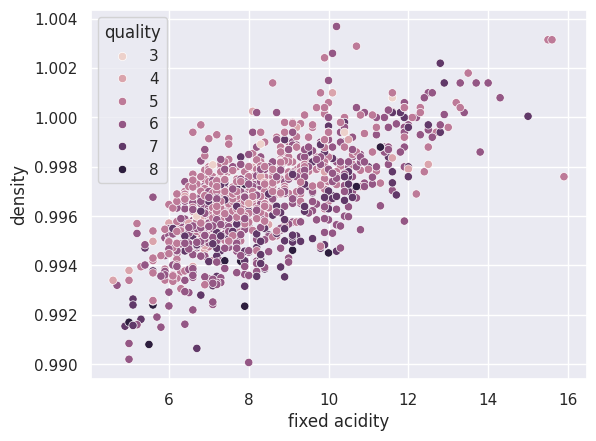

In [223]:
sns.scatterplot(x = 'fixed acidity',y = 'density',hue = 'quality',data = exploration_set )

<Axes: xlabel='fixed acidity', ylabel='density'>

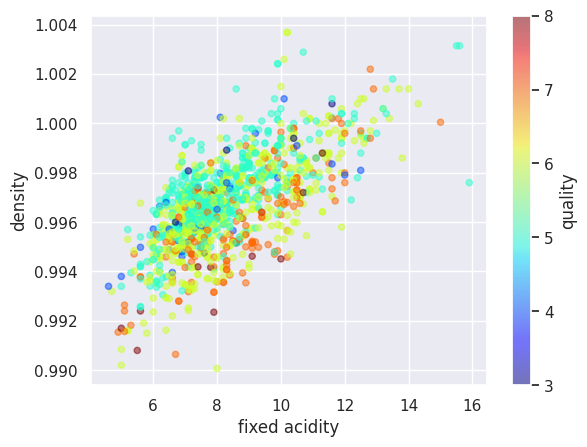

In [224]:
exploration_set.plot(kind = 'scatter',x = 'fixed acidity',y = 'density',c = "quality",alpha = 0.5,cmap=plt.get_cmap("jet"))

<Axes: >

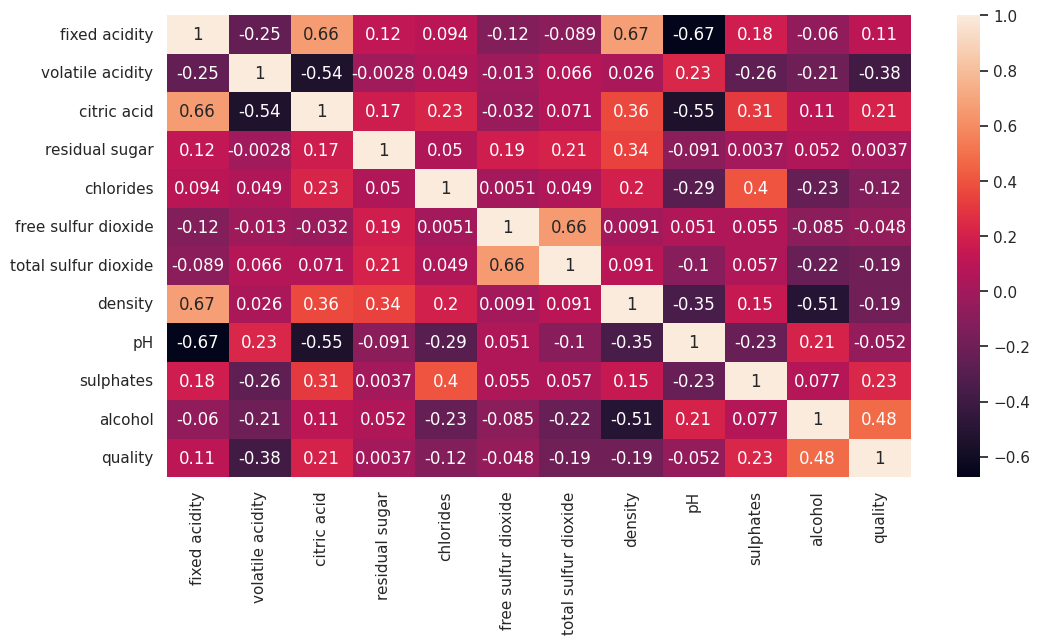

In [225]:
plt.figure(figsize = (12,6))
corr_matrix = exploration_set.corr()
sns.heatmap(corr_matrix,annot = True)

In [226]:
corr_matrix['quality']

,quality
fixed acidity,0.107940
volatile acidity,-0.383249
citric acid,0.210802
residual sugar,0.003710
chlorides,-0.120231
free sulfur dioxide,-0.048291
total sulfur dioxide,-0.194511
density,-0.193009
pH,-0.052063
sulphates,0.228050


In [227]:
#train data
wine_features_train = strata_train_set.drop('quality',axis = 1)
wine_label_train = strata_train_set['quality'].copy()


#test data

wine_features_test = strata_test_set.drop('quality',axis = 1)
wine_label_test = strata_test_set['quality']

In [228]:
wine_features_train.isna().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [230]:
wine_features_test.isna().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


Preprocessing and Model Building par

In [232]:
pipeline = Pipeline(steps = [('imputer',SimpleImputer(strategy = 'median')),('std_scaler',StandardScaler())])


In [233]:
line_reg = LinearRegression()
wine_feature_train_tr = pipeline.fit_transform(wine_features_train)
line_reg = LinearRegression()
line_reg.fit(wine_feature_train_tr,wine_label_train)

LinearRegression()

In [234]:
train_pred = line_reg.predict(wine_feature_tr)
mean_squared_error(train_pred,wine_label_train)

0.4206571060060278

In [235]:
wine_feature_test_tr = pipeline.fit_transform(wine_features_test)

In [236]:
 test_predc =  line_reg.predict(wine_features_test_tr)

mean_squared_error(test_predc ,wine_label_test)

0.3975913087501519

Text(0, 0.5, 'predicted quality')

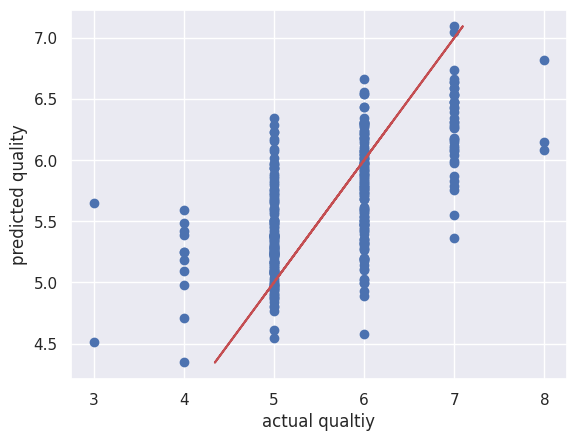

In [237]:
plt.scatter(wine_label_test,quality_test_predc)
plt.plot(test_predc,test_predc,'r-')
plt.xlabel('actual qualtiy')
plt.ylabel('predicted quality')

In [238]:

tree_reg = DecisionTreeRegressor()
tree_reg.fit(wine_feature_train_tr,wine_label_train)

DecisionTreeRegressor()

In [239]:
tree_reg.fit(wine_feature_train_tr,wine_label_train)
train_pred = tree_reg.predict(wine_feature_train_tr)
mean_squared_error(train_pred,wine_label_train)


0.0

In [240]:
test_pred = tree_reg.predict(wine_features_test_tr)
mean_squared_error(wine_label_test,test_pred)

0.596875

In [241]:
def display_scores(scores):
  print('scores:', scores)
  print('mean:',scores.mean())
  print('standard_dev:',scores.std())

In [242]:
scores = cross_val_score(line_reg,wine_feature_train_tr,wine_label_train,scoring = 'neg_mean_squared_error',cv = 10)
lin_reg_mse = -scores
display_scores(lin_reg_mse)

scores: [0.56364537 0.4429824  0.38302744 0.40166681 0.29687635 0.37322622
 0.33184855 0.50182048 0.51661311 0.50468542]
mean: 0.431639217212196
standard_dev: 0.08356359730413968


In [243]:
scores = cross_val_score(tree_reg,wine_feature_train_tr,wine_label_train,scoring = 'neg_mean_squared_error',cv = 10)
line_reg_mse = -scores
display_scores(line_reg_mse)

scores: [0.671875   0.7421875  0.59375    0.578125   0.4765625  0.5703125
 0.671875   0.7109375  0.75       0.95275591]
mean: 0.6718380905511812
standard_dev: 0.12442741009643364


In [244]:
forest_reg = RandomForestRegressor()
forest_reg.fit(wine_feature_train_tr,wine_label_train)

RandomForestRegressor()

In [245]:
scores = cross_val_score(forest_reg,wine_feature_train_tr,wine_label_train,scoring = 'neg_mean_squared_error',cv = 10)
forest_reg_mse = -scores
display_scores(forest_reg_mse)

scores: [0.37874063 0.42172422 0.28013125 0.32078125 0.22631094 0.28612891
 0.27256875 0.37252891 0.42813359 0.47201811]
mean: 0.345906654773622
standard_dev: 0.0764284884697014


In [246]:
test_predc = forest_reg.predict(wine_feature_test_tr)

In [247]:
mean_squared_error(test_predc,wine_label_test)

0.33970593750000005

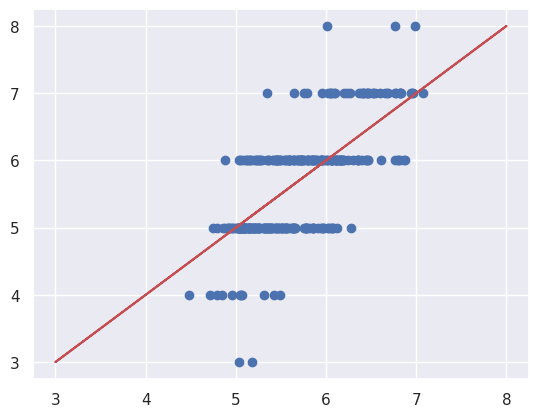

In [248]:
plt.scatter(test_predc,wine_label_test)
plt.plot(wine_label_test,wine_label_test,'r-')

Hyper Parameter Tunning

In [249]:
param_grid = [{'n_estimators':[3,10,30],'max_features':[2,4,6,8]},{'bootstrap':[False],'n_estimators':[3,10],'max_features':[2,3,4]}]

In [250]:
grid_search = GridSearchCV(forest_reg,param_grid,cv=5,scoring = 'neg_mean_squared_error',return_train_score = True)

In [251]:
grid_search.fit(wine_feature_train_tr,wine_label_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid=[{'max_features': [2, 4, 6, 8],
                          'n_estimators': [3, 10, 30]},
                         {'bootstrap': [False], 'max_features': [2, 3, 4],
                          'n_estimators': [3, 10]}],
             return_train_score=True, scoring='neg_mean_squared_error')

In [252]:
grid_search.best_params_

{'max_features': 8, 'n_estimators': 30}

In [253]:
cvres = grid_search.cv_results_
for mean_score,params in zip(cvres['mean_test_score'],cvres['params']):
  print(-mean_score,params)

0.45452648420479297 {'max_features': 2, 'n_estimators': 3}
0.3946829350490196 {'max_features': 2, 'n_estimators': 10}
0.3588683278867102 {'max_features': 2, 'n_estimators': 30}
0.4565025871459694 {'max_features': 4, 'n_estimators': 3}
0.40815876225490194 {'max_features': 4, 'n_estimators': 10}
0.35963692470043573 {'max_features': 4, 'n_estimators': 30}
0.4801000816993463 {'max_features': 6, 'n_estimators': 3}
0.38230762867647056 {'max_features': 6, 'n_estimators': 10}
0.3654692742374727 {'max_features': 6, 'n_estimators': 30}
0.48578431372549014 {'max_features': 8, 'n_estimators': 3}
0.3826812806372549 {'max_features': 8, 'n_estimators': 10}
0.3557741115196078 {'max_features': 8, 'n_estimators': 30}
0.44751736111111107 {'bootstrap': False, 'max_features': 2, 'n_estimators': 3}
0.360759375 {'bootstrap': False, 'max_features': 2, 'n_estimators': 10}
0.4671452886710239 {'bootstrap': False, 'max_features': 3, 'n_estimators': 3}
0.3715591299019607 {'bootstrap': False, 'max_features': 3, 'n_

In [254]:
grid_search.best_estimator_

RandomForestRegressor(max_features=8, n_estimators=30)

In [255]:
imp_features = grid_search.best_estimator_.feature_importances_
imp_features

array([0.05569525, 0.13162578, 0.04712009, 0.05608925, 0.06213959,
       0.04731805, 0.07794349, 0.06123888, 0.05897067, 0.14196163,
       0.25989732])

In [256]:
features_list =wine_features_train.columns.to_list()

In [257]:
sorted(zip(imp_features, features_list), reverse=True)

[(np.float64(0.2598973212883779), 'alcohol'),
 (np.float64(0.14196163306721696), 'sulphates'),
 (np.float64(0.1316257758844533), 'volatile acidity'),
 (np.float64(0.07794349219727784), 'total sulfur dioxide'),
 (np.float64(0.062139591948182776), 'chlorides'),
 (np.float64(0.0612388759947166), 'density'),
 (np.float64(0.0589706679440271), 'pH'),
 (np.float64(0.05608924963073717), 'residual sugar'),
 (np.float64(0.05569525130687239), 'fixed acidity'),
 (np.float64(0.04731805392306461), 'free sulfur dioxide'),
 (np.float64(0.047120086815073584), 'citric acid')]

In [258]:
test_pred = grid_search.best_estimator_.predict(wine_features_test_tr)

In [259]:
mean_squared_error(wine_label_test,test_predc)

0.33970593750000005

In [260]:
confidence = 0.95
squared_errors = (test_pred-wine_label_test)**2
stats.t.interval(confidence,len(squared_errors)-1,loc = squared_errors.mean(),scale = stats.sem(squared_errors))

(np.float64(0.28073940273540887), np.float64(0.4171217083757024))